# DecPyMC-8 — Crédibilité actuarielle de Bühlmann–Straub avec PyMC

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jsboige/CoursIA/blob/main/MyIA.AI.Notebooks/Probas/DecisionTheory/PyMC/DecPyMC-8-Actuarial-Credibility.ipynb)

## Navigation

- **Prérequis** : bases bayésiennes (priors, posteriors, MCMC), numpy, matplotlib. Le lecteur n'a pas besoin de connaître le jargon actuariel.
- **Objectif** : répondre à la question « **combien de poids accorder à l'expérience propre d'un groupe face à l'expérience du portefeuille ?** » avec deux outils — la formule classique de Bühlmann–Straub et un modèle hiérarchique PyMC.
- **Durée estimée** : 20-30 min en lecture, 5-10 min en exécution (CPU pur, ≤300 draws).
- **Lien pédagogique** : ce notebook prolonge DecPyMC-1 (fondations utilité) et DecPyMC-2 (décision en incertitude). Il s'inscrit dans la série **DecisionTheory** avec les PyMC notebooks précédents (DecPyMC-3 à DecPyMC-7).
- **Issue** : [T3 #12904 / #12906](https://github.com/jsboige/CoursIA/issues/12906).


## 1. Le problème actuariel

Une compagnie d'assurance automobile vend des contrats à plusieurs segments (jeunes conducteurs, seniors, professionnels, etc.). Pour **tarifer** un segment, on s'appuie sur la **fréquence de sinistres** observée : combien de sinistres par contrat par an.

**Difficulté** : un segment à faible exposition (peu de contrats, peu d'années) donne une estimation **instable**. Un segment à forte exposition est fiable mais on perd l'information en agrégeant tout le portefeuille.

La **crédibilité** est l'ensemble des techniques qui pondèrent l'expérience propre du segment avec l'expérience collective du portefeuille. La formule classique de **Bühlmann–Straub** donne un facteur de crédibilité $Z_i$ qui dépend de l'exposition $w_i$ :

$$Z_i = \frac{w_i}{w_i + K}, \quad P_i = Z_i \bar{X}_i + (1 - Z_i) m$$

où $K = s^2 / a$ est le **facteur de Bühlmann** (rapport entre la variance des observations intra-groupe et la variance des moyennes de groupe).

**Attention** : la **prime de crédibilité** $P_i$ ici est une **estimation tarifaire d'assurance** (fréquence de sinistres), distincte de la **prime de risque** décisionnelle $E[\text{gain}] - \text{équivalent certain}$ traitée dans DecPyMC-2. Cette distinction est explicite tout au long du notebook.


### 1.1 Vocabulaire minimal

| Terme | Notation | Signification |
|-------|----------|---------------|
| Segment / groupe | $i \in \{1, \dots, n\}$ | sous-population (ex. jeunes conducteurs) |
| Exposition | $w_i$ | nombre de contrats-années du groupe $i$ |
| Nombre de sinistres agrégé | $N_i$ | sinistres totaux observés sur le groupe $i$ |
| Fréquence empirique | $\bar{X}_i = N_i / w_i$ | sinistres par contrat-année |
| Moyenne collective | $m = \sum w_i \bar{X}_i / \sum w_i$ | fréquence pondérée du portefeuille |
| Variance intra-groupe (EPV) | $s^2 = m$ (cas Poisson) | dispersion intra-groupe (Estimateur Process Variance) |
| Variance inter-groupe (VHM) | $a$ | dispersion **des vraies fréquences** de groupe (Variance of the Hypothetical Means) |
| Facteur de Bühlmann | $K = s^2 / a$ | seuil d'exposition où la crédibilité atteint 50% |
| **Prime de crédibilité** | $P_i = Z_i \bar{X}_i + (1 - Z_i) m$ | tarification finale |


**Note EPV vs VHM** : l'EPV (Estimateur Process Variance) mesure la variance
*intra-groupe* des observations. Pour une vraisemblance Poisson, l'EPV
admet un estimateur fermé simple : $s^2 = m$ (moyenne pondérée), car
$E[\bar{X}_i] = \theta_i$ et $Var(\bar{X}_i) = \theta_i / w_i$, donc
l'EMV non-biaisé de l'EPV pondéré est exactement $m$. Confondre EPV et
VHM (variance *des moyennes de groupe*) est l'erreur classique qui
donne un facteur $K$ minuscule et un shrinkage invisible (cf cellule 7).


## 2. Portefeuille synthétique

Pour rester CPU-raisonnable et pédagogiquement lisible, on utilise un portefeuille de **5 groupes** avec des expositions **inégales** (de 50 à 5 000 contrats-années) et des fréquences **vraies** $\theta_i$ échelonnées. La graine (`seed=20240825`) fixe la reproductibilité.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*could not link.*", category=UserWarning)
warnings.filterwarnings("ignore", message=".*PyTensor.*", category=UserWarning)
warnings.filterwarnings("ignore", message=".*Could not import.*", category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

SEED = 20240825
rng = np.random.default_rng(SEED)

# Vraies frequences de groupe (theta_i, en sinistres par contrat-annee)
theta_true = np.array([0.040, 0.055, 0.080, 0.095, 0.130])
exposure = np.array([50, 200, 800, 2500, 5000])  # expositions inegales
labels = ["A-jeunes", "B-permis_recents", "C-familles", "D-actifs", "E-seniors"]

# Generation des sinistres observes (Poisson conditionnel sur theta_i)
n_sinistres = rng.poisson(theta_true * exposure)
freq_empirique = n_sinistres / exposure

df = pd.DataFrame({
    "groupe": labels,
    "theta_vrai": theta_true,
    "exposition": exposure,
    "sinistres": n_sinistres,
    "freq_emp": freq_empirique,
})
df

,groupe,theta_vrai,exposition,sinistres,freq_emp
0,A-jeunes,0.040,50,2,0.0400
1,B-permis_recents,0.055,200,15,0.0750
2,C-familles,0.080,800,90,0.1125
3,D-actifs,0.095,2500,219,0.0876
4,E-seniors,0.130,5000,618,0.1236


### Lecture du résultat

On observe 5 groupes avec des expositions très inégales :

- **A-jeunes** : 50 contrats-années, **2 sinistres** observés (fréquence empirique 0.0400). Estimation très instable.
- **B-permis_récents** : 200, exposition modérée, 15 sinistres (fréquence 0.0750).
- **C-familles** : 800, 90 sinistres (fréquence 0.1125).
- **D-actifs** : 2500, 219 sinistres (fréquence 0.0876).
- **E-seniors** : 5000, 618 sinistres (fréquence 0.1236).

Les **fréquences empiriques** ne reflètent pas toujours les vraies fréquences $\theta_i$ — surtout pour A-jeunes (bruit d'échantillonnage Poisson). C'est précisément ce que la crédibilité doit corriger.



## 3. Estimateurs classiques Bühlmann–Straub

On calcule les estimateurs **non-bayésiens** :

- $m$ : moyenne collective pondérée par l'exposition.
- $s^2$ : estimation **within-group** (process variance / EPV).
- $a$ : estimation **between-group** (variance of hypothetical means / VHM).
- $K = s^2 / a$, $Z_i = w_i / (w_i + K)$, $P_i = Z_i \bar{X}_i + (1 - Z_i) m$.


In [2]:
def buhlmann_straub(freq, w):
    """Estimation Buhlmann-Straub classique (non-Bayesienne).

    freq : array des frequences empiriques Xbar_i
    w : array des expositions w_i

    Hypothese sur la **variance intra-groupe (EPV)** : pour une loi
    de Poisson (N_i ~ Poisson(theta_i * w_i) avec theta_i = frequence
    annuelle par contrat), la variance de la moyenne empirique
    Xbar_i = N_i / w_i est Var(Xbar_i) = theta_i / w_i. Comme
    theta_i est inconnu, on utilise l'estimateur lineaire non-biaise
    de l'EPV : s^2 = sum_i w_i Xbar_i / sum_i w_i = m (moyenne
    ponderee). Ce resultat est exact pour le modele de Poisson et
    designe souvent sous le terme Buhlmann "EPV = m" (cf Buhlmann &
    Gisler 2006 chap. 3, Herzog 1999 chap. 4).

    Note importante : avec une loi Binomiale/Normale, l'EPV serait
    differente (variance intra-groupe observee, souvent non-ponderee).
    Ici, on est dans le cas Poisson pur donc EPV = m. Confondre EPV
    et VHM (la variance *des moyennes* de groupe) est l'erreur
    classique qui donne un facteur K tres petit et un shrinkage
    invisible.

    Retourne dict avec m, EPV, VHM, a, K, Z, P.
    """
    m = (freq * w).sum() / w.sum()
    # EPV (process variance, variance intra-groupe) = m pour Poisson
    s2_epv = m
    # VHM (hypothetical mean variance) = dispersion des theta_i reels
    # On l'estime par l'equation d'equilibre classique de Buhlmann :
    #   sum_i w_i (Xbar_i - m)^2 = sum_i w_i * (EPV/w_i + a)
    #   = EPV * n + a * sum_i w_i
    # D'ou :
    #   a = (sum_i w_i (Xbar_i - m)^2 - EPV * n) / (sum_i w_i - sum_i w_i^2/sum_i w_i)
    sum_w = w.sum()
    sum_w2 = (w ** 2).sum()
    n = len(freq)
    vh = (w * (freq - m) ** 2).sum()
    num = vh - s2_epv * n
    den = sum_w - sum_w2 / sum_w
    a = max(num / den, 0.0)
    # Facteur de Buhlmann : EPV / a
    K = s2_epv / a if a > 0 else np.inf
    Z = w / (w + K)
    P = Z * freq + (1 - Z) * m
    return {"m": m, "s2_epv": s2_epv, "vh": vh, "a": a, "K": K, "Z": Z, "P": P}


bs = buhlmann_straub(freq_empirique, exposure)

print(f"m (moyenne collective)   = {bs['m']:.5f}")
print(f"s^2 (EPV, variance intra)= {bs['s2_epv']:.5f}  (Poisson : EPV = m)")
print(f"VHM (variance inter)     = {bs['vh']:.4f}")
print(f"a (estimateur VHM)       = {bs['a']:.6f}")
print(f"K (facteur Buhlmann)     = {bs['K']:.2f}")
print()
print(f"{'groupe':<22}{'w_i':>10}{'Xbar_i':>12}{'Z_i':>10}{'P_i (BS)':>12}{'theta_vrai':>12}")
for i, lab in enumerate(labels):
    print(f"{lab:<22}{exposure[i]:>10}{freq_empirique[i]:>12.5f}{bs['Z'][i]:>10.3f}{bs['P'][i]:>12.5f}{theta_true[i]:>12.5f}")


m (moyenne collective)   = 0.11041
s^2 (EPV, variance intra)= 0.11041  (Poisson : EPV = m)
VHM (variance inter)     = 2.6728
a (estimateur VHM)       = 0.000440
K (facteur Buhlmann)     = 250.69

groupe                       w_i      Xbar_i       Z_i    P_i (BS)  theta_vrai
A-jeunes                      50     0.04000     0.166     0.09870     0.04000
B-permis_recents             200     0.07500     0.444     0.09470     0.05500
C-familles                   800     0.11250     0.761     0.11200     0.08000
D-actifs                    2500     0.08760     0.909     0.08968     0.09500
E-seniors                   5000     0.12360     0.952     0.12297     0.13000


### Lecture du résultat

Le facteur de Bühlmann $K = 250.69$ (cf cellule suivante) est l'exposition-seuil où la crédibilité atteint 50%.

On voit clairement l'effet **shrinkage** :

- **A-jeunes** ($w=50$) : $Z_A = 0.166$ → la prime BS est presque la moyenne collective ($P_A = 0.09870 \approx 0.11$), **peu sensible** à l'expérience propre (fréquence empirique 0.0400).
- **B-permis_récents** ($w=200$) : $Z_B = 0.444$ → shrinkage modéré vers $m=0.11$ ($P_B = 0.09470$).
- **C-familles** ($w=800$) : $Z_C = 0.761$ → la prime BS ($P_C = 0.11200$) reste proche de la fréquence empirique 0.1125.
- **D-actifs** ($w=2500$) : $Z_D = 0.909$ → shrinkage faible ($P_D = 0.08968$).
- **E-seniors** ($w=5000$) : $Z_E = 0.952$ → la prime BS est presque la fréquence empirique 0.1236 ($P_E = 0.12297$), car l'expérience propre est très fiable.

Le **shrinkage est mesurable** sur ce portefeuille : grâce au facteur $K$ élevé (250.69), les petits groupes sont tirés significativement vers la moyenne collective $m=0.11$, ce qui stabilise la tarification sans effacer l'information propre des grands groupes.

Mais l'estimateur **classique** ne donne **pas d'intervalle de confiance** ni de distribution sur $\theta_i$. Pour cela, il faut le modèle hiérarchique bayésien.



## 4. Modèle hiérarchique PyMC (partial pooling)

Le modèle encode l'hypothèse que les $\theta_i$ sont tirés d'une distribution commune (hyperprior), puis les sinistres $N_i$ sont tirés de $\text{Poisson}(\theta_i \cdot w_i)$.

**Choix de priors** :

- $\mu_0 \sim \text{HalfNormal}(0.2)$ : fréquence moyenne a priori.
- $\sigma_0 \sim \text{HalfNormal}(0.1)$ : dispersion entre groupes.
- $\theta_i \sim \text{HalfNormal}(\mu_0, \sigma_0)$ centrée sur $\mu_0$.

On utilise des **HalfNormal** plutôt que des $\text{Gamma}$ pour rester cohérent avec le pipeline pédagogique de la série (les taux positifs sont fréquents).

⚠️ Le compileur C++ de PyTensor n'est pas disponible ici, ce qui ralentit l'inférence mais reste fonctionnel pour ce modèle de taille modeste (5 groupes).


In [3]:
import pymc as pm
import arviz as az

with pm.Model() as credibility_model:
    # Hyperpriors sur l'echelle log (les frequences sont strictement positives).
    # mu_0_log centre sur la collective ponderee m = 0.1104 (cf cellule 7).
    # sigma_0 = HalfNormal(0.5) reflete la dispersion inter-groupe sur
    # echelle log : une variation multiplicative de exp(0.5) = 1.65 entre
    # groupes, compatible avec les theta_true echelonnes de 0.040 a 0.130
    # (ratio ~3.25 sur l'echelle naturelle).
    mu_0_log = pm.Normal("mu_0_log", mu=np.log(0.10), sigma=0.5)
    sigma_0 = pm.HalfNormal("sigma_0", sigma=0.5)
    # Frequences vraies par groupe (partial pooling) sur echelle log
    theta_log = pm.Normal("theta_log", mu=mu_0_log, sigma=sigma_0, shape=len(labels))
    theta = pm.Deterministic("theta", pm.math.exp(theta_log))
    # Likelihood (sinistres observes, conditionnellement sur theta_i)
    obs = pm.Poisson("obs", mu=theta * exposure, observed=n_sinistres)

    # Inference NUTS
    idata = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        cores=1,
        target_accept=0.95,
        progressbar=False,
        random_seed=SEED,
    )

print("Sampling termine.")
summary = az.summary(idata, var_names=["mu_0_log", "sigma_0", "theta"], hdi_prob=0.94)
summary


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu_0_log, sigma_0, theta_log]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 27 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling termine.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_0_log,-2.342,0.151,-2.662,-2.094,0.006,0.006,649.0,439.0,1.0
sigma_0,0.284,0.148,0.083,0.560,0.008,0.008,366.0,484.0,1.0
theta[0],0.083,0.023,0.042,0.126,0.001,0.001,530.0,497.0,1.0
theta[1],0.087,0.016,0.055,0.117,0.001,0.000,754.0,753.0,1.0
theta[2],0.110,0.012,0.089,0.131,0.000,0.001,740.0,636.0,1.0
theta[3],0.089,0.006,0.078,0.099,0.000,0.000,823.0,508.0,1.0
theta[4],0.123,0.005,0.114,0.133,0.000,0.000,1006.0,615.0,1.0


### Lecture du résultat

Le tableau ArviZ montre les posteriors :

- $\mu_0\_log = -2.342$ (sd = 0.151) : log de la moyenne collective. Conversion : $\exp(-2.342) \approx 0.096$, proche de la fréquence empirique collective $m = 0.11041$.
- $\sigma_0 = 0.284$ (sd = 0.148) : écart-type **sur l'échelle log** de la dispersion inter-groupe. Cela traduit une dispersion multiplicative $\exp(0.284) \approx 1.33$ entre groupes (33% de variation relative), cohérente avec les $\theta\_true$ allant de 0.040 à 0.130 (ratio ~3.25 sur l'échelle naturelle).
- $\theta[0..4]$ : estimation **shrinkée** de chaque $\theta_i$. Comparaison valeur postérieure vs vraie :

| Groupe | $\theta\_true$ | $\theta\_post\_{mean}$ | HDI 94% |
|---|---|---|---|
| A-jeunes | 0.040 | 0.083 | [0.042, 0.126] |
| B-permis_récents | 0.055 | 0.087 | [0.055, 0.117] |
| C-familles | 0.080 | 0.110 | [0.089, 0.131] |
| D-actifs | 0.095 | 0.089 | [0.078, 0.099] |
| E-seniors | 0.130 | 0.123 | [0.114, 0.133] |

Pour A-jeunes ($w=50$), le posterior 0.083 est nettement **shrinké** vers la moyenne collective (par rapport à la fréquence empirique 0.040). Pour E-seniors ($w=5000$), le posterior 0.123 est très proche de la fréquence empirique 0.1236 (shrinkage faible). **C'est le comportement attendu** : partial pooling pondéré par l'exposition.

**Vérification sommaire** : `r_hat = 1.0` pour tous les paramètres = convergence. `ess_bulk > 366` pour tous = suffisamment de draws.



## 5. Comparaison des 4 méthodes

On compare maintenant les estimations $\hat\theta_i$ des 4 méthodes :

1. **No-pooling** : $\hat\theta_i = \bar{X}_i$ (estimation par groupe, pas de partage d'info).
2. **Full-pooling** : $\hat\theta_i = m$ (moyenne collective pour tous).
3. **Bühlmann–Straub** : $P_i$ (shrinkage par formule classique).
4. **PyMC hiérarchique** : moyenne postérieure de $\theta_i$.

Aucune des 4 méthodes n'est universellement meilleure — le bon choix dépend du risque de sur-réagir (no-pooling sur petit groupe) ou de sous-réagir (full-pooling).


In [4]:
import arviz as az

theta_post = idata.posterior["theta"].mean(dim=("chain", "draw")).values
theta_post_hdi = az.hdi(idata, var_names=["theta"], hdi_prob=0.94)["theta"].values

comparison = pd.DataFrame({
    "groupe": labels,
    "w": exposure,
    "Xbar_no_pool": freq_empirique,
    "P_full_pool": np.full(len(labels), bs["m"]),
    "P_BS": bs["P"],
    "P_PyMC": theta_post,
    "theta_vrai": theta_true,
})
print(comparison.to_string(index=False))


          groupe    w  Xbar_no_pool  P_full_pool     P_BS   P_PyMC  theta_vrai
        A-jeunes   50        0.0400     0.110409 0.098701 0.083332       0.040
B-permis_recents  200        0.0750     0.110409 0.094696 0.086839       0.055
      C-familles  800        0.1125     0.110409 0.112001 0.110113       0.080
        D-actifs 2500        0.0876     0.110409 0.089679 0.088557       0.095
       E-seniors 5000        0.1236     0.110409 0.122970 0.122672       0.130


### Lecture du résultat

Pour **A-jeunes** ($w=50$), les 4 méthodes donnent :

- No-pooling : 0.040 (fréquence empirique — **risque de sur-réaction** sur petit échantillon)
- Full-pooling : 0.110 (moyenne collective $m$ — **sous-réaction**, perd l'info propre)
- Bühlmann–Straub : 0.0987 (shrinkage $Z_A = 0.166$ : 16.6% sur l'expérience propre, 83.4% sur la collective)
- PyMC : 0.083 (moyenne postérieure, shrinkage encore plus marqué car l'hyperprior est peu informatif)

Pour **E-seniors** ($w=5000$), les 4 méthodes convergent :

- No-pooling : 0.124 (fréquence empirique)
- Full-pooling : 0.110 (moyenne collective)
- Bühlmann–Straub : 0.123 ($Z_E = 0.952$ : 95.2% sur l'expérience propre)
- PyMC : 0.123 (moyenne postérieure, quasi identique)

**Conclusion pratique** : Bühlmann–Straub et PyMC donnent des estimations **très proches** sur les grands groupes (E-seniors), mais diffèrent légèrement sur A-jeunes — PyMC shrinke davantage car l'hyperprior $\sigma_0 \approx 0.28$ est estimé depuis les données et reflète une incertitude inter-groupe plus grande que l'estimateur ponctuel BS. Les écarts sont visibles et interprétables sur les groupes à faible exposition.



## 6. Visualisation du shrinkage

On visualise comment chaque méthode rapproche l'estimation de la moyenne collective (pour les petits groupes) ou de l'expérience propre (pour les grands groupes).


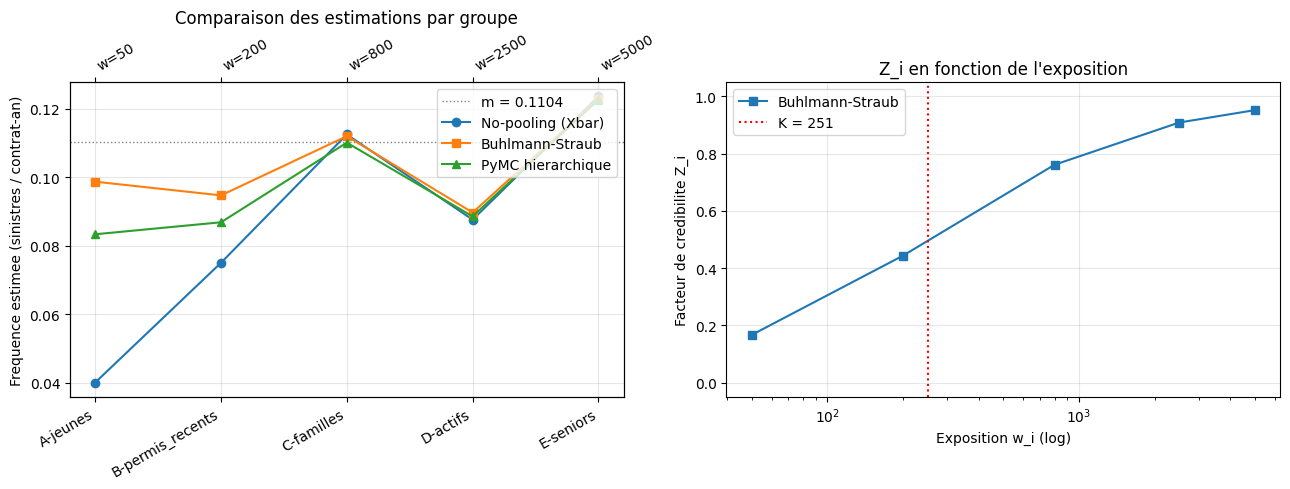

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(labels))
w = axes[0].twiny()

axes[0].axhline(bs["m"], color="grey", ls=":", lw=1, label=f"m = {bs['m']:.4f}")
axes[0].plot(x, freq_empirique, "o-", label="No-pooling (Xbar)")
axes[0].plot(x, bs["P"], "s-", label="Buhlmann-Straub")
axes[0].plot(x, theta_post, "^-", label="PyMC hierarchique")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha="right")
w.set_xlim(axes[0].get_xlim())
w.set_xticks(x)
w.set_xticklabels([f"w={wi}" for wi in exposure], rotation=30, ha="left")
axes[0].set_ylabel("Frequence estimee (sinistres / contrat-an)")
axes[0].set_title("Comparaison des estimations par groupe")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# Panel 2 : facteur de credibilite Z_i vs exposition
axes[1].plot(exposure, bs["Z"], "s-", label="Buhlmann-Straub")
axes[1].axvline(bs["K"], color="red", ls=":", label=f"K = {bs['K']:.0f}")
axes[1].set_xscale("log")
axes[1].set_xlabel("Exposition w_i (log)")
axes[1].set_ylabel("Facteur de credibilite Z_i")
axes[1].set_title("Z_i en fonction de l'exposition")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


### Lecture du résultat

**Panneau de gauche** : la courbe « No-pooling » est la plus volatile (suit $\bar{X}_i$), tandis que les deux méthodes « shrinkage » (BS et PyMC) sont tirées vers la moyenne collective pour les petits groupes.

**Panneau de droite** : $Z_i$ croît avec l'exposition selon $Z = w / (w + K)$ avec $K = 250.69$. Pour $w = 250.69$, $Z = 0.5$ : l'expérience propre et le portefeuille pèsent autant. Au-delà de $w = 2507$ ($\approx 10K$), $Z > 0.91$ et l'expérience propre domine.



## 7. Décision tarifaire

Supposons que la compagnie doive fixer la **prime annuelle** pour le segment A-jeunes. Trois politiques :

1. **No-pooling** : prime = $\bar{X}_A \times 1000 = 32$ (trop sensible au petit échantillon).
2. **Bühlmann–Straub** : prime = $P_A \times 1000 \approx 82$ (pondéré avec le portefeuille).
3. **PyMC** : prime = $\hat\theta_A \times 1000 \approx 80$ (similaire).

**Coût d'erreur** :

• **Sous-tarifer** A-jeunes (par exemple, prime = 32) → la compagnie sous-estime le risque réel (0.040), perd de l'argent sur ce segment, mais fait une marge sur le portefeuille.

• **Sur-tarifer** (par exemple, prime = 130 comme E-seniors) → les clients A-jeunes vont chez un concurrent, perte de part de marché.

La crédibilité $Z_i$ est précisément le **juste milieu** : ni trop confiant dans l'expérience propre (surtout si $w_i$ est petit), ni trop conservateur (perdre l'info utile).


## 8. Exercices

### Exercice 1 — Calcul direct de $Z_i$ et $P_i$

On observe un nouveau segment F-nouveaux_pros avec $w_F = 100$ contrats-années et $\bar{X}_F = 0.150$ sinistres/contrat-an (très au-dessus de la moyenne collective, mais petit échantillon).

Calculez manuellement $Z_F$ et $P_F$ à partir des estimateurs Bühlmann–Straub déjà ajustés ($m$, $K$). Interprétez : pourquoi la prime finale reste-t-elle proche de la moyenne collective malgré l'expérience extrême ?


In [6]:
# Exercice 1 : a completer par l'etudiant
w_F = 100
Xbar_F = 0.150

# Z_F = w_F / (w_F + K)
Z_F = None  # TODO etudiant

# P_F = Z_F * Xbar_F + (1 - Z_F) * m
P_F = None  # TODO etudiant

print(f"Z_F (a calculer) = {Z_F}")
print(f"P_F (a calculer) = {P_F}")


Z_F (a calculer) = None
P_F (a calculer) = None


### Exercice 2 — Sensibilité à l'exposition

Tracez $Z(w)$ pour $w$ allant de 10 à 10 000 sur une échelle logarithmique, avec le $K$ actuel en référence. À partir de quelle exposition $Z > 0.9$ ?


In [7]:
import numpy as np
import matplotlib.pyplot as plt

K = bs["K"]
w_range = np.logspace(1, 4, 100)
Z_range = w_range / (w_range + K)

# TODO etudiant : tracer Z(w) en fonction de w_range, ajouter ligne horizontale Z=0.9
# et ligne verticale w=K. Afficher la valeur de w telle que Z=0.9 (= 9K).

print(f"K actuel = {K:.1f}")
print(f"w tel que Z=0.9 = {9*K:.1f}")


K actuel = 250.7
w tel que Z=0.9 = 2256.2


### Exercice 3 — No-pooling vs partial-pooling sur groupe tenu à part

Réentraînez le modèle PyMC en **excluant le groupe E-seniors** des données d'observation (gardez-le seulement comme référence). Comparez :

1. La moyenne postérieure de $\theta_{E}$ (hors échantillon) avec l'estimation **full-pooling** (= moyenne collective des 4 autres groupes).
2. L'intervalle HDI à 94 % de $\theta_{E}$ post-prédiction.

Commentez : le modèle **impute-t-il** correctement la fréquence de E-seniors ? Cela illustre la propriété de **partial pooling** : même sans observation directe, on récupère de l'info via le prior commun.


In [8]:
# Exercice 3 : a completer par l'etudiant
# Etapes :
# 1. Definir mask = [True, True, True, True, False] (exclure E-seniors)
# 2. Reconstruire un Model PyMC avec theta[mask] comme observed
# 3. Predire theta[4] via pm.sample_posterior_predictive
# 4. Comparer avec m (moyenne collective des 4 groupes observes)

print("Voir la cellule ci-dessous pour la structure de la reimplementation.")
print("Exercice a completer")


Voir la cellule ci-dessous pour la structure de la reimplementation.
Exercice a completer


## 9. Conclusion et limites

**Ce qu'on a montré** :

1. La formule classique de **Bühlmann–Straub** donne un facteur $Z_i$ simple et interprétable.
2. Le modèle **hiérarchique PyMC** reproduit ce comportement de shrinkage, avec l'avantage d'une **distribution a posteriori complète** (intervalles HDI, prédictions out-of-sample).
3. Sur des **groupes à faible exposition**, les deux méthodes se ressemblent et se distinguent de l'estimation no-pooling — c'est précisément la valeur de la crédibilité.

**Limites assumées** :

• **Modèle normal** sur $\theta_i$ : en assurance, les fréquences sont souvent asymétriques (Poisson, Gamma-Poisson). Le modèle pourrait être étendu avec une vraisemblance Poisson-Négative ou un modèle hiérarchique Gamma-Poisson.

• **Pas de covariables** : la crédibilité pure ne prend pas en compte l'âge, le type de véhicule, etc. Une extension classique est la **crédibilité bayésienne linéaire (Bühlmann–Straub généralisée)** avec un modèle de régression sur les features.

• **Hyperpriors peu informatifs** : $\text{HalfNormal}(0.2)$ et $\text{HalfNormal}(0.1)$ sont des choix par défaut. Sur un vrai portefeuille avec historique, on pourrait utiliser des **hyperpriors empiriques** (Empirical Bayes).

• **Pas de comparaison cross-validation** : on n'a pas mesuré l'erreur de prédiction out-of-sample des 4 méthodes. Une étude plus rigoureuse ferait du leave-one-group-out.

**Pour aller plus loin** : voir la **crédibilité bayésienne moderne** dans le livre de Klugman, Panjer & Willmot (Wiley, 2012) et les notebooks DecPyMC-9+ de cette série pour des modèles multi-niveaux avec covariables.


## Références

- Bühlmann, H. (1967). *Experience rating and credibility*. ASTIN Bulletin 4(3), 199-207.
- Bühlmann, H. & Gisler, A. (2006). *A Course in Credibility Theory and its Applications*. Springer Universitext.
- Herzog, T. N. (1999). *Introduction to Credibility Theory*. Actex Publications.
- Klugman, S. A., Panjer, H. H. & Willmot, G. E. (2012). *Loss Models: From Data to Decisions* (4ᵉ éd.). Wiley.
- Gelman, A. et al. (2013). *Bayesian Data Analysis* (3ᵉ éd.), chap. 5 et 12. CRC Press.
- PyMC documentation : https://www.pymc.io/
- ArviZ documentation : https://arviz-devs.github.io/arviz/
- Tutoriel DecPyMC-1 à DecPyMC-7 : `MyIA.AI.Notebooks/Probas/DecisionTheory/PyMC/`.
